In [1]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import numpy as np

from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import copy
from pathlib import Path
import random
from PIL import Image


In [13]:
# import torch.nn.functional as F


In [2]:
# list comprehension
tmp = 'c1b5p7qwe876!I0'
print([n for n in tmp if n in '0123456789'])

# filter
flt = filter(lambda n: n in '0123456789', tmp)
print(list(flt))

['1', '5', '7', '8', '7', '6', '0']
['1', '5', '7', '8', '7', '6', '0']


In [3]:

class MobileNetV3Finetune(nn.Module):
    def __init__(self, class_labels):
        super(MobileNetV3Finetune, self).__init__()
        self.num_classes = len(class_labels)
        self.class_labels = class_labels
        
        # Instanciação do modelo via timm
        self._model = timm.create_model(
            'mobilenetv3_small_100', 
            pretrained=True, 
            num_classes=self.num_classes
        )
        self.transform = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)

    def forward(self, x):
        return self._model(x)

    def prepare_train(self, unfreeze_blocks=2):
        # Variáveis de histórico
        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }
        self.best_model_wts = None
        self.best_acc = 0.0

        # congela tudo
        for param in self._model.parameters():
            param.requires_grad = False
            
        # parametros de classificacao - descongelar
        for param in self._model.classifier.parameters():
            param.requires_grad = True
            
        # descongela algumas camadas finais (blocos de features)
        # MobileNetV3 tem blocos em model.blocks - vc tem que pesquisar sobre a rede escolhida
        # ou pode dar print para examinar os nomes das camadas
        for block in list(self._model.blocks)[-unfreeze_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
        
        print(f"Modelo preparado: {unfreeze_blocks} blocos finais e classifier descongelados.")

    def configure_preprocessing(self, pad=True):
        input_size = 224
        if pad:
            def pad_to_target(img):
                w, h = img.size
                if w > input_size or h > input_size:
                    img.thumbnail((input_size, input_size))
                    w, h = img.size

                pad_w = input_size - w
                pad_h = input_size - h
                
                padding = (
                    pad_w // 2,               # esquerda
                    pad_h // 2,               # topo
                    pad_w - (pad_w // 2),     # direita
                    pad_h - (pad_h // 2)      # base
                )
                return transforms.functional.pad(img, padding, fill=0, padding_mode='constant')

            self.transform = transforms.Compose([
                transforms.Lambda(pad_to_target),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((input_size, input_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def _get_dataloaders(self, data_dir, batch_size=32):
        full_dataset = ImageFolder(root=data_dir, transform=self.transform)
        train_idx, val_idx = train_test_split(
            np.arange(len(full_dataset)),
            test_size=0.1,
            shuffle=True,
            random_state=42
        )
        
        train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=batch_size, shuffle=False)
        
        return train_loader, val_loader

    def _preprocess_pil_list(self, pil_images):
        if self.transform is None:
            raise ValueError("O pré-processamento não foi configurado. Chame configure_preprocessing() primeiro.")
        
        batch_tensor = torch.stack([self.transform(img) for img in pil_images])
        return batch_tensor.to(self.device)

    def predict_batch(self, pil_images):
        if not pil_images:
            return []

        self.eval()
        input_batch = self._preprocess_pil_list(pil_images)

        with torch.no_grad():
            outputs = self(input_batch)
            _, preds = torch.max(outputs, 1)

        probs = F.softmax(outputs, dim=1)
        results = []
        for idx_img, p in enumerate(preds):
            idx_classe = p.item()
            results.append({
                'class_id': idx_classe,
                'label': self.class_labels[idx_classe],
                'probs': probs[idx_img],
            })
            
        return results

    def save_model(self, model_path='mobilenet_weights.pth'):
        torch.save(self.state_dict(), model_path)

    def load_model(self, model_path='mobilenet_weights.pth'):
        try:
            checkpoint = torch.load(model_path, map_location=self.device)
            self.load_state_dict(checkpoint)
            print(f"Pesos carregados com sucesso de: {model_path}")
        except Exception as e:
            print(f"Erro ao carregar pesos: {e}")

    def train_model(self, data_dir, epochs=5, lr=1e-3):
        train_loader, val_loader = self._get_dataloaders(data_dir)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam([p for p in self.parameters() if p.requires_grad], lr=lr)
        # optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=lr)
        self.best_model_wts = copy.deepcopy(self.state_dict())
        self.best_acc = 0.0
        for epoch in range(epochs):
            self.train()
            running_loss = 0.0
            correct = 0
            total = 0
            pbar = tqdm(train_loader, desc=f"Época {epoch} - Treino")
            num_batch = 0
            for inputs, labels in pbar:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                # Estatísticas
                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                current_loss = running_loss / total
                current_acc = 100 * correct / total
                pbar.set_postfix({
                    'loss': f'{current_loss:.4f}',
                    'acc': f'{current_acc:.2f}%'
                })
                num_batch += 1
                # if num_batch == 50: break

            epoch_loss = running_loss / total
            epoch_acc = correct / total
            
            val_loss, val_acc = self.validate_model(val_loader, criterion)
            # Registro do Histórico
            self.history['train_loss'].append(epoch_loss)
            self.history['train_acc'].append(epoch_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc / 100.0)
            # Salvar melhor modelo
            if val_acc > self.best_acc:
                self.best_acc = val_acc
                self.best_model_wts = copy.deepcopy(self.state_dict())
                self.save_model(f"mobilenet_weights_ep{epoch}_acc0{int(10*val_acc)}.pth")
            
            print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Val Acc: {val_acc:.2f}%")

    def validate_model(self, val_loader=None, criterion=None):
        if val_loader is None:
            if data_dir is None:
                print("Informe val_loader ou data_dir")
                return None, None
                
            train_loader, val_loader = self._get_dataloaders(data_dir)

        if criterion is None: criterion = nn.CrossEntropyLoss()
            
        self.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f"Validacao")
            num_batch = 0
            for inputs, labels in pbar:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                current_loss = val_loss / total
                current_acc = 100 * correct / total
                pbar.set_postfix({
                    'loss': f'{current_loss:.4f}',
                    'acc': f'{current_acc:.2f}%'
                })
                num_batch += 1
                # if num_batch == 50: break
        
        accuracy = 100. * correct / total
        return val_loss / len(val_loader), accuracy

    def plot_history(self):
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.figure(figsize=(12, 5))

        # Gráfico de Loss
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history['train_loss'], 'b-', label='Treino')
        plt.plot(epochs, self.history['val_loss'], 'r-', label='Validação')
        plt.title('Loss por Época')
        plt.xlabel('Épocas')
        plt.ylabel('Loss')
        plt.legend()

        # Gráfico de Acurácia
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history['train_acc'], 'b-', label='Treino')
        plt.plot(epochs, self.history['val_acc'], 'r-', label='Validação')
        plt.title('Acurácia por Época')
        plt.xlabel('Épocas')
        plt.ylabel('Acurácia')
        plt.legend()

        plt.tight_layout()
        plt.show()


In [4]:
cifar_dataset_path_train = "../cifar10/train"
classes_br = ['aviao', 'carro', 'ave', 'gato', 'cervo', 
              'cachorro', 'sapo', 'cavalo', 'navio', 'caminhao']

mn_model = MobileNetV3Finetune(classes_br)
mn_model.configure_preprocessing(pad=True)
mn_model.prepare_train(unfreeze_blocks=2)


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Modelo preparado: 2 blocos finais e classifier descongelados.


In [5]:
mn_model.train_model(cifar_dataset_path_train, epochs=20, lr=1e-3)

Validacao: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:09<00:00, 15.87it/s, loss=1.2395, acc=46.00%]


Epoch 1/20 - Loss: 1.6007 - Val Acc: 46.00%


Validacao: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:08<00:00, 18.67it/s, loss=1.5121, acc=44.72%]


Epoch 2/20 - Loss: 1.4146 - Val Acc: 44.72%


Validacao: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:08<00:00, 18.34it/s, loss=0.7451, acc=50.04%]


...

Epoch 18/20 - Loss: 0.9108 - Val Acc: 55.98%


Validacao: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:08<00:00, 18.43it/s, loss=13.5478, acc=55.28%]


Epoch 19/20 - Loss: 0.8919 - Val Acc: 55.28%


Validacao: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:08<00:00, 18.53it/s, loss=5.7412, acc=56.00%]

Epoch 20/20 - Loss: 0.8682 - Val Acc: 56.00%


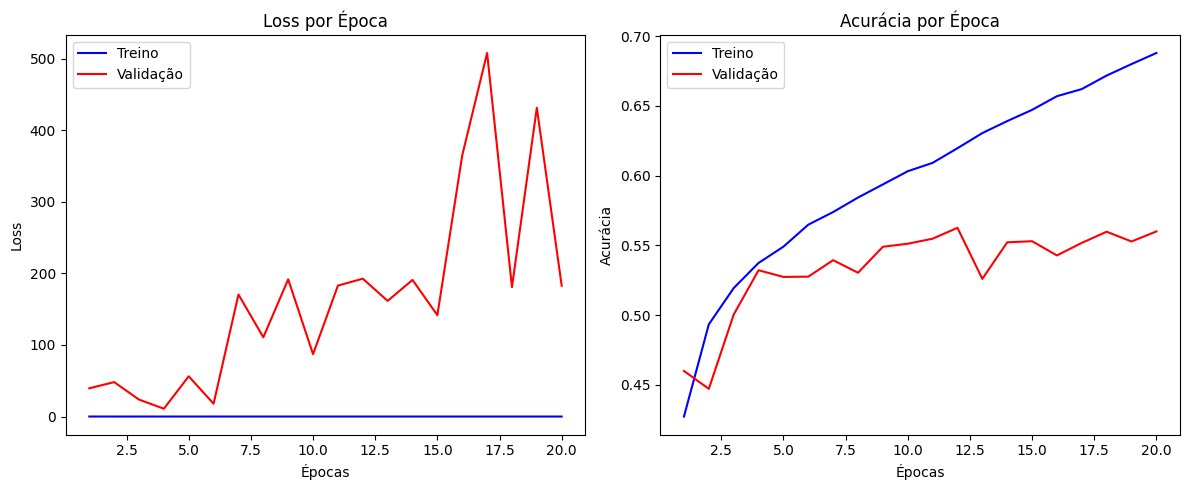

In [6]:
mn_model.plot_history()

In [6]:
train_loader, val_loader = mn_model._get_dataloaders(cifar_dataset_path_train)
criterion = nn.CrossEntropyLoss()
val_loss, val_acc = mn_model.validate_model(val_loader, criterion)
print(val_acc)

Validacao: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [01:22<00:00,  1.91it/s, loss=1.6345, acc=52.26%]

52.26


In [9]:
cifar_test = "/Users/joaomacedo/LocalDev/datasets/cifar10/test"
extensoes = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
lista_pil = []
path_pai = Path(cifar_test)
subpastas = [f for f in path_pai.iterdir() if f.is_dir()]
for cl_dir in subpastas:
    arqs = [p for p in cl_dir.rglob('*') if p.suffix.lower() in extensoes]
    if arqs:
        amostra = random.sample(arqs, min(len(arqs), 3))
        for p in amostra:
            try:
                img = Image.open(p).convert('RGB')
                lista_pil.append(img)
            except Exception as e:
                print(f"Erro ao abrir {p.name}: {e}")


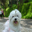

In [21]:
mn_model.plot_history()

In [14]:
predicoes = mn_model.predict_batch(lista_pil)

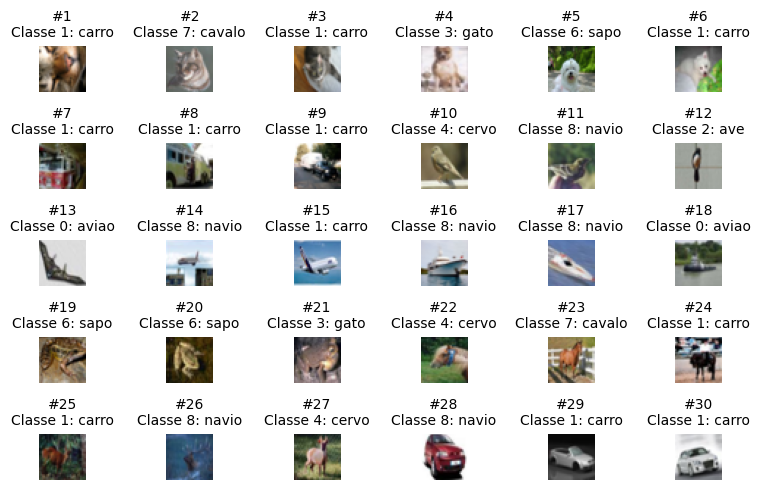

In [25]:
num_images = len(lista_pil)
num_predictions = len(predicoes)

num_rows = 5
num_cols = 6
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 5))
axes_flat = axes.flatten()

for idx in range(num_images):
    ax = axes_flat[idx]
    img = lista_pil[idx]
    pred = predicoes[idx]
    class_id = pred['class_id']
    label = pred['label']
    ax.imshow(img)
    ax.set_title(f"#{idx+1}\nClasse {class_id}: {label}", 
                 fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()